## ESZA019 – Visao Computacional 2026.2
## Laboratório 2 –  Extração  de  Características Features

### Integrantes: 

- Eduarda Alexandre de Salles RA: 11202320551

- Gustavo de Paula Souza RA: 11202130568

- Paloma Cristina Santana RA:11201921396


#### Data de realização: 03/06/2026

#### Data de publicação: 14/06/2026



## 1. INTRODUÇÃO

Esta seção aborda os fundamentos teóricos necessários para a compreensão e implementação dos experimentos práticos de detecção, descrição e casamento de características locais em imagens e fluxos de vídeo.

### 1.1. Entendendo o Conceito de Features

As características (*features*) são pontos de interesse contidos numa imagem que se destacam geometricamente ou texturalmente em relação à sua vizinhança imediata. Elas representam descontinuidades de padrões visuais locais, tais como cantos, bordas pronunciadas ou manchas de alta intensidade. Uma analogia intuitiva é pensar na imagem como um **quebra-cabeça**: as peças mais fáceis de alinhar são sempre aquelas que possuem "cantos", quinas ou texturas marcantes, enquanto peças que representam regiões homogêneas (como um céu azul liso) são quase impossíveis de se posicionar visualmente.

Para o computador, fazer uma detecção de *features* consiste simplesmente em buscar as partes da imagem onde há a maior quantidade de variação de intensidade. Estruturalmente, elas funcionam como âncoras ou assinaturas matemáticas estáveis. Isso permite a algoritmos de computação visual correlacionar e rastrear o mesmo objeto tridimensional ou elemento de cenário mesmo quando submetido a mudanças drásticas de perspectiva espacial, variações nas condições de iluminação ambiental ou transformações de escala geométrica. O fluxo de trabalho padrão divide-se em:

* **Detecção:** Encontrar a localização física desses pontos de interesse na imagem.
* **Descrição:** Descrever matematicamente a vizinhança dessas partes detectadas para que o computador possa assimilar, comparar e reconhecer as mesmas características em outras imagens.

---

### 1.2. Detector de Cantos de Harris (Harris Corner Detector)

O método de Harris formula a detecção de cantos avaliando a mudança matemática de intensidade local produzida pelo deslocamento infinitesimal de uma janela local ($[u, v]$) sobre uma região da imagem ($I$). Matematicamente, a variação de intensidade $E(u,v)$ é expressa por:

$$E(u,v) = \sum_{x,y} w(x,y)[I(x+u, y+v) - I(x,y)]^2$$

Onde $w(x,y)$ define a função de janela (seja uma janela retangular ou uma Gaussiana que atribui pesos aos pixels). Através da expansão em Série de Taylor, a equação pode ser simplificada numa forma matricial:

$$E(u,v) \approx \begin{bmatrix} u & v \end{bmatrix} M \begin{bmatrix} u \\ v \end{bmatrix}$$

A Matriz de Estrutura Local ($M$) é dada pela covariância dos gradientes de imagem nas direções horizontal ($I_x$) e vertical ($I_y$), que podem ser facilmente obtidos por operadores de derivada como o de Sobel:

$$M = \sum_{x,y} w(x,y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$$

O algoritmo computa uma função de resposta ao canto ($R$), dada por:

$$R = \text{det}(M) - k \cdot (\text{trace}(M))^2$$

Onde $\text{det}(M) = \lambda_1 \lambda_2$, $\text{trace}(M) = \lambda_1 + \lambda_2$, e $k$ é uma constante empírica (comumente calibrada entre $0.04$ e $0.06$).

A magnitude dos autovalores ($\lambda_1$ e $\lambda_2$) classifica a região da janela analisada:

1. **Região Plana (Flat):** Quando $\lambda_1$ e $\lambda_2$ são pequenos, $R$ é pequeno e a intensidade é estável.
2. **Borda (Edge):** Quando $R < 0$ (o que ocorre quando um autovalor é muito maior que o outro), indicando variação em apenas uma direção.
3. **Canto (Corner):** Se os autovalores forem ambos grandes e positivos, $R$ assume um valor alto, caracterizando matematicamente uma variação brusca em todas as direções de deslocamento.

O resultado prático da função é uma imagem em escala de cinza contendo esses scores de intensidade. Ao aplicar um limiar (*threshold*) adequado sobre essa matriz de respostas, isolam-se os cantos exatos na imagem.

#### Refinamento com Precisão de Subpixel

Em cenários onde a acurácia geométrica máxima é crucial (como calibração de sensores), as coordenadas inteiras de pixels devolvidas pelo detector de Harris podem ser insuficientes. Utiliza-se então o refinamento por **Subpixel Accuracy**. A partir dos centroides brutos dos cantos, o algoritmo avalia iterativamente os vetores gradientes da vizinhança matemática. Como o vetor gradiente é ortogonal à borda, o ponto onde o produto escalar entre o gradiente e o vetor de deslocamento se anula define o vértice exato do canto com precisão decimal.

---

### 1.3. Detector de Shi-Tomasi (Good Features to Track)

Proposto como uma otimização direta do detector de Harris, o algoritmo de Shi-Tomasi introduz uma modificação na função de pontuação de canto ($R$). Ao analisar a estabilidade matemática para rastreamento de fluxos ópticos, os autores demonstraram que a classificação de um canto é mais robusta quando baseada unicamente no limitante inferior dos autovalores da matriz $M$. A função simplificada é definida por:

$$R = \min(\lambda_1, \lambda_2)$$

A região avaliada é consolidada como um canto válido se, e somente se, o menor autovalor for estritamente maior que um limiar mínimo pré-estipulado ($\lambda_{\text{min}}$).

Ao calcular diretamente o menor dos autovalores, esse critério remove a dependência do parâmetro empírico $k$ da equação de Harris. Além de simplificar a tomada de decisão matemática, a abordagem de Shi-Tomasi garante uma distribuição mais homogênea e estável de pontos-chave sob deformações afins, permitindo filtrar e ordenar facilmente os melhores cantos por ordem de relevância, tornando-o ideal para algoritmos de rastreamento temporal.

---

### 1.4. SIFT (Scale-Invariant Feature Transform)

Diferente dos métodos anteriores que operam de forma estática numa resolução fixa — e falham se a imagem sofrer alteração de escala (pois um canto expandido em zoom deixa de se comportar como canto dentro de uma janela fixa) —, o algoritmo SIFT extrai pontos de interesse que apresentam invariância robusta frente a variações de escala e rotação geométrica. O processo divide-se em cinco etapas principais:

1. **Detecção de Extremos no Espaço de Escala:** Para simular a percepção do objeto em múltiplos tamanhos, a imagem é sucessivamente convoluída com núcleos Gaussianos em diferentes escalas ($\sigma$) e subamostrada, gerando uma estrutura piramidal de oitavas. A subtração matemática entre escalas consecutivas gera o espaço de Diferença de Gaussianas (**DoG - Difference of Gaussians**), que aproxima eficientemente o Laplaciano do Gaussiano atuando como um detector de manchas (*blobs*). Os pontos-chave candidatos são os extremos locais (máximos e mínimos) detectados comparando cada pixel com os seus 8 vizinhos na mesma imagem, 9 na escala superior e 9 na escala inferior (26 vizinhos tridimensionais no espaço e na escala).
2. **Localização do Ponto-Chave:** Utiliza-se a expansão em Série de Taylor do espaço de escala para refinar a localização dos extremos com precisão matemática. Pontos candidatos que exibem baixo contraste (intensidade abaixo de um limiar predefinido) são automaticamente descartados. Adicionalmente, elimina-se respostas espúrias localizadas ao longo de bordas instáveis através do cálculo da curvatura principal via matriz Hessiana local.
3. **Atribuição de Orientação:** Calcula-se a magnitude e a direção do gradiente de intensidade na vizinhança de cada ponto-chave de acordo com a sua escala correspondente. Cria-se um histograma de orientação composto por 36 *bins* para cobrir os $360^\circ$. A maior direção dominante é atribuída ao ponto, garantindo a **invariância à rotação**. Picos secundários que possuam até 80% da magnitude do pico principal geram um novo ponto-chave com mesma coordenada e escala, mas direção distinta, aumentando a estabilidade no casamento.
4. **Descritor de Ponto-Chave:** Uma vizinhança de $16 \times 16$ pixels ao redor do ponto é isolada e rotacionada com base na sua orientação atribuída. Essa região é subdividida em sub-regiões menores de $4 \times 4$ pixels. Para cada sub-região, calcula-se um histograma de orientações com 8 *bins* de direção. O resultado consolida um vetor descritor altamente discriminativo de **128 dimensões** ($4 \times 4 \times 8$), normalizado ao final para mitigar efeitos de variações de iluminação e contraste global.
5. **Casamento de Pontos (Keypoint Matching):** A correspondência entre pontos-chave de imagens distintas é feita calculando a distância Euclidiana entre seus descritores de 128 dimensões. Como ruídos ou texturas repetitivas podem gerar falsas associações, aplica-se o **Teste de Razão de Lowe (Lowe's Ratio Test)**: avalia-se a razão de distância entre o vizinho mais próximo e o segundo vizinho mais próximo. Se essa proporção for maior que $0.8$, o casamento é rejeitado por ambiguidade. Esse critério estatístico elimina cerca de 90% dos casamentos incorretos enquanto preserva quase a totalidade das correspondências verdadeiras.

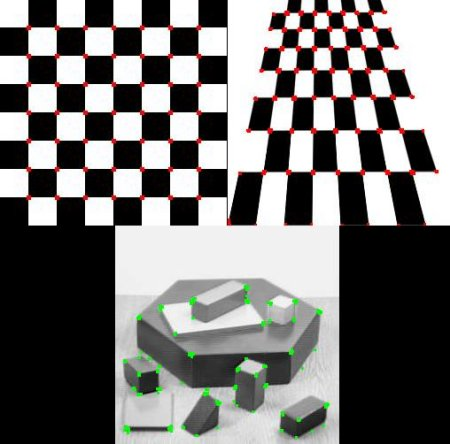


## 2. PROCEDIMENTOS EXPERIMENTAIS

Esta seção documenta a lógica operacional adotada no desenvolvimento dos programas em Python e OpenCV para a validação dos conceitos de casamento de características e homografia.

### 2.1. PARTE 2 (A): Feature Matching e Homografia Estática

Para a primeira atividade prática, foi desenvolvido um script estruturado para carregar duas imagens previamente registradas no sistema de arquivos local. A imagem `foto.png` representou o objeto de consulta isolado, enquanto a imagem `video1.png` representou o cenário complexo onde o objeto se encontrava em uma posição distinta.

O procedimento experimental seguiu o seguinte fluxo lógico:

* **Detecção:** O extrator SIFT foi instanciado para mapear os pontos de interesse e computar os vetores descritores de 128 dimensões para ambas as imagens.
* **Pareamento:** Os descritores foram processados pelo combinador baseado no algoritmo FLANN (*Fast Library for Approximate Nearest Neighbors*), configurado com árvores KD-Tree indexadas para otimizar o tempo de busca em alta dimensão.
* **Filtragem:** Aplicou-se o Teste de Razão de Lowe com fator limite de $0.7$ para rejeitar correspondências ambíguas ou falsos-positivos.
* **Mapeamento Geométrico:** Através da função de busca de homografia associada ao algoritmo RANSAC, calculou-se a matriz de transformação perspectiva estável. Caso o número de pontos válidos superasse o limiar mínimo configurado para 20 correspondências, o algoritmo projetava as coordenadas das quinas do objeto original sobre a cena, delimitando sua localização exata por meio de um polígono colorido.

In [3]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

MIN_MATCH_COUNT = 20

img1 = cv.imread('foto.png', cv.IMREAD_GRAYSCALE)          # queryImage
img2 = cv.imread('video1.png', cv.IMREAD_GRAYSCALE) # trainImage

# Initiate SIFT detector
sift = cv.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)

flann = cv.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1,des2,k=2)

# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append(m)
    if len(good)>MIN_MATCH_COUNT:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC,5.0)
        matchesMask = mask.ravel().tolist()

        h,w = img1.shape
        pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts,M)

        img2 = cv.polylines(img2,[np.int32(dst)],True,255,3, cv.LINE_AA)
    else:
        print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
        matchesMask = None

draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)

img3 = cv.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)

# plt.imshow(img3, 'gray'),plt.show()
cv.imwrite('sfit.png',img3)

Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found - 0/20
Not enough matches are found

True


### 2.2. PARTE 2 (B): Feature Matching Estereoscópico Dinâmico

Para expandir o experimento analítico para o domínio temporal, modificou-se a arquitetura do programa anterior para dar suporte ao processamento paralelo e simultâneo de hardware. Em vez de arquivos estáticos em disco, o pipeline passou a capturar os fluxos de vídeo em tempo real gerados por duas webcams configuradas em um arranjo estereoscópico calibrado.

A dinâmica adaptada operou sob as seguintes restrições:

* Implementação de um laço de repetição contínuo acoplado aos barramentos de captura de vídeo, realizando a leitura síncrona dos quadros correspondentes à câmera esquerda e à câmera direita.
* Conversão imediata e obrigatória de cada par de quadros para a escala de cinza para compatibilização matemática com o pipeline do SIFT.
* Execução paralela da detecção de pontos-chave e extração de descritores nos fluxos esquerdo e direito.
* Realização do casamento de características via FLANN em tempo de execução, desenhando dinamicamente as linhas de correspondência válidas entre as duas telas integradas e exibindo o resultado instantaneamente em uma janela unificada de vídeo até o comando de interrupção pelo usuário.


In [1]:
import numpy as np
import cv2 as cv

MIN_MATCH_COUNT = 10

# 1. Inicializa as duas webcams
cap_left = cv.VideoCapture(0)
cap_right = cv.VideoCapture(2)

# Captura um frame inicial para descobrir a largura (w) e altura (h) das câmeras
ret_l, frame_l = cap_left.read()
ret_r, frame_r = cap_right.read()

if not ret_l or not ret_r:
    print("Erro ao acessar as webcams. Verifique as conexões.")
    cap_left.release()
    cap_right.release()
    exit()

h, w, _ = frame_l.shape

# 2. Configuração dos gravadores de vídeo (VideoWriter)
# 'XVID' é um codec amplamente compatível para formato .avi
fourcc = cv.VideoWriter_fourcc(*'XVID')
fps = 20.0  # Taxa de quadros por segundo padrão para webcams comuns

out_left = cv.VideoWriter('video_esquerda_puro.avi', fourcc, fps, (w, h))
out_right = cv.VideoWriter('video_direita_puro.avi', fourcc, fps, (w, h))
# O vídeo do SIFT junta as duas imagens lado a lado, logo a largura é o dobro (w * 2)
out_sift = cv.VideoWriter('resultado_estereoscopia_sift.avi', fourcc, fps, (w * 2, h))

# Inicializa o detector SIFT e FLANN Matcher
sift = cv.SIFT_create()
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

print("Gravando... Clique na janela do vídeo e pressione 'q' para salvar e sair.")

while True:
    # 3. Captura o frame de ambas as câmeras
    ret_l, frame_l = cap_left.read()
    ret_r, frame_r = cap_right.read()

    if not ret_l or not ret_r:
        print("Erro ao capturar frames durante a gravação.")
        break

    # Grava os feeds puros das câmeras antes de qualquer modificação visual (retângulos, linhas)
    out_left.write(frame_l)
    out_right.write(frame_r)

    # Converte para escala de cinza para o processamento do SIFT
    gray_l = cv.cvtColor(frame_l, cv.COLOR_BGR2GRAY)
    gray_r = cv.cvtColor(frame_r, cv.COLOR_BGR2GRAY)

    # Detecta os keypoints e descritores
    kp1, des1 = sift.detectAndCompute(gray_l, None)
    kp2, des2 = sift.detectAndCompute(gray_r, None)

    # Cria uma cópia do frame direito para desenhar os efeitos do SIFT sem alterar o original gravado
    frame_r_sift = frame_r.copy()

    if des1 is not None and des2 is not None:
        matches = flann.knnMatch(des1, des2, k=2)

        # Filtro pelo teste de razão de Lowe
        good = []
        for m, n in matches:
            if m.distance < 0.7 * n.distance:
                good.append(m)

        if len(good) > MIN_MATCH_COUNT:
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

            M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
            matchesMask = mask.ravel().tolist()

            # Desenha o retângulo outline no frame cópia da direita
            pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
            
            if M is not None:
                dst = cv.perspectiveTransform(pts, M)
                frame_r_sift = cv.polylines(frame_r_sift, [np.int32(dst)], True, (0, 255, 0), 3, cv.LINE_AA)
        else:
            matchesMask = None
            
        draw_params = dict(matchColor=(0, 255, 0),
                           singlePointColor=None,
                           matchesMask=matchesMask,
                           flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

        # Cria a imagem combinada lado a lado com os matches usando a cópia modificada da direita
        output_video = cv.drawMatches(frame_l, kp1, frame_r_sift, kp2, good, None, **draw_params)
    else:
        output_video = np.hstack((frame_l, frame_r))

    # Grava o frame processado pelo SIFT
    out_sift.write(output_video)

    # Exibe na tela para você acompanhar o que está sendo gravado
    cv.imshow('Gravando Estereoscopia (Pressione Q para Sair)', output_video)

    # Interrompe o loop ao pressionar a tecla 'q' na janela de exibição
    if cv.waitKey(1) & 0xFF == ord('q'):
        print("Finalizando e salvando os arquivos de vídeo...")
        break

# 4. Libera TODOS os recursos e fecha os arquivos corretamente para não corromper os vídeos
cap_left.release()
cap_right.release()
out_left.release()
out_right.release()
out_sift.release()
cv.destroyAllWindows()
print("Vídeos salvos com sucesso!")

Gravando... Clique na janela do vídeo e pressione 'q' para salvar e sair.


QFontDatabase: Cannot find font directory /home/ufabc/anaconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/anaconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/anaconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/anaconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font dire

Finalizando e salvando os arquivos de vídeo...
Vídeos salvos com sucesso!



## 3. ANÁLISE E DISCUSSÃO DOS ESTUDOS REALIZADOS

Os experimentos práticos evidenciaram as nuances operacionais e limitações dos métodos implementados:

1. **Robustez Matemática vs. Desempenho:** Conforme fundamentado, o SIFT oferece alta invariância a rotações e variações geométricas rigorosas. Contudo, a geração e o casamento de descritores de 128 dimensões impõem um elevado custo computacional. Nos testes de execução em vídeo em tempo real, observou-se uma queda na taxa de quadros por segundo (FPS) quando a densidade de *keypoints* no cenário aumentava substancialmente, limitando o seu uso direto em sistemas embarcados restritos sem aceleração por hardware.
2. **Filtragem de Casamentos Falsos (Inliers):** O teste de razão de Lowe fixado em $0.7$ mostrou-se imprescindível. Sem ele, ambiguidades geradas por texturas repetitivas ou ruído de alta frequência produzem falsas associações geométricas. O método RANSAC atuou de forma eficiente, isolando estes ruídos matemáticos e garantindo uma estimativa correta da homografia projetiva planar.

### 3.1. Aplicação Prática Proposta para o Trabalho Final da Disciplina

As técnicas estudadas neste laboratório fornecem a base algorítmica essencial para a modelagem do trabalho final da equipe, focado em **reconstrução tridimensional estereoscópica e odometria visual**.

A extração de pontos-chave estáveis através do SIFT permite estabelecer correspondências homólogas robustas entre a imagem da câmera esquerda e a da câmera direita. Dispondo dos parâmetros intrínsecos e extrínsecos da câmera estéreo previamente calibrada, calcula-se o mapa de disparidade. A disparidade calculada pela diferença das coordenadas horizontais ($d = x_l - x_r$) possibilita extrair geometricamente a informação de profundidade absoluta ($Z$) dos objetos através do modelo de triangulação estéreo clássico:

$$Z = \frac{B \cdot f}{d}$$

Onde $B$ representa a distância de linha de base (*baseline*) entre os eixos ópticos das webcams e $f$ denota a distância focal efetiva obtida na calibração. Paralelamente, o rastreamento temporal dessas características correlacionadas permite estimar a matriz essencial entre quadros consecutivos, viabilizando o cálculo da trajetória cinemática do sistema robótico no espaço por meio de odometria visual.


## 4. CONCLUSÕES

O laboratório possibilitou fixar de forma sólida os conceitos matemáticos por trás da representação de imagens por meio de características locais de baixo nível. A transição prática de códigos que operam sobre matrizes estáticas para pipelines dinâmicos de vídeo em tempo real evidenciou desafios práticos de engenharia e visão computacional. Lidar com problemas reais como a latência de sincronismo do barramento USB, flutuação na taxa de quadros (FPS), manipulação concorrente de múltiplos fluxos de hardware e tratamento de oclusões espaciais são competências críticas absorvidas pelo grupo, fundamentais para o desenvolvimento do projeto final da disciplina.


## 5. REFERÊNCIAS CONSULTADAS 

BRADSKI, Gary; KAEHLER, Adrian. **Learning OpenCV**: Computer vision with the OpenCV library. Sebastopol: O'Reilly Media, Inc., 2008.

LOWE, David G. Distinctive image features from scale-invariant keypoints. **International Journal of Computer Vision**, v. 60, n. 2, p. 91-110, 2004.

OPENCV. **Feature Detection and Description**. OpenCV 4.x Documentation. Disponível em: [https://docs.opencv.org/](https://www.google.com/search?q=https://docs.opencv.org/). Acesso em: 07 jun. 2026.

OPENCV. **Introduction to SIFT (Scale-Invariant Feature Transform)**. Disponível em: [https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html](https://www.google.com/search?q=https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html). Acesso em: 07 jun. 2026.

OPENCV. **Harris Corner Detection**. Disponível em: [https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html](https://www.google.com/search?q=https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html). Acesso em: 07 jun. 2026.

OPENCV. **Shi-Tomasi Corner Detector & Good Features to Track**. Disponível em: [https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html](https://www.google.com/search?q=https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html). Acesso em: 07 jun. 2026.

OPENCV. **Feature Matching + Homography to find Objects**. Disponível em: [https://docs.opencv.org/4.x/d1/de6/tutorial_py_homography.html](https://www.google.com/search?q=https://docs.opencv.org/4.x/d1/de6/tutorial_py_homography.html). Acesso em: 07 jun. 2026.